Nama: Prieyuda Akadita S
NIM: 240401010353
Kelas: IF403

In [1]:
print("Install library... harap tunggu")
!python -m pip install -q pandas numpy requests scipy matplotlib seaborn
print("Library berhasil diinstal")

Install library... harap tunggu
Library berhasil diinstal



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Ukuran dataset tips: (244, 7)

Ringkasan Statistik Data Numerik:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00

Rata-rata Total Tagihan per Hari:
day
Thur    17.68
Fri     17.15
Sat     20.44
Sun     21.41
Name: total_bill, dtype: float64


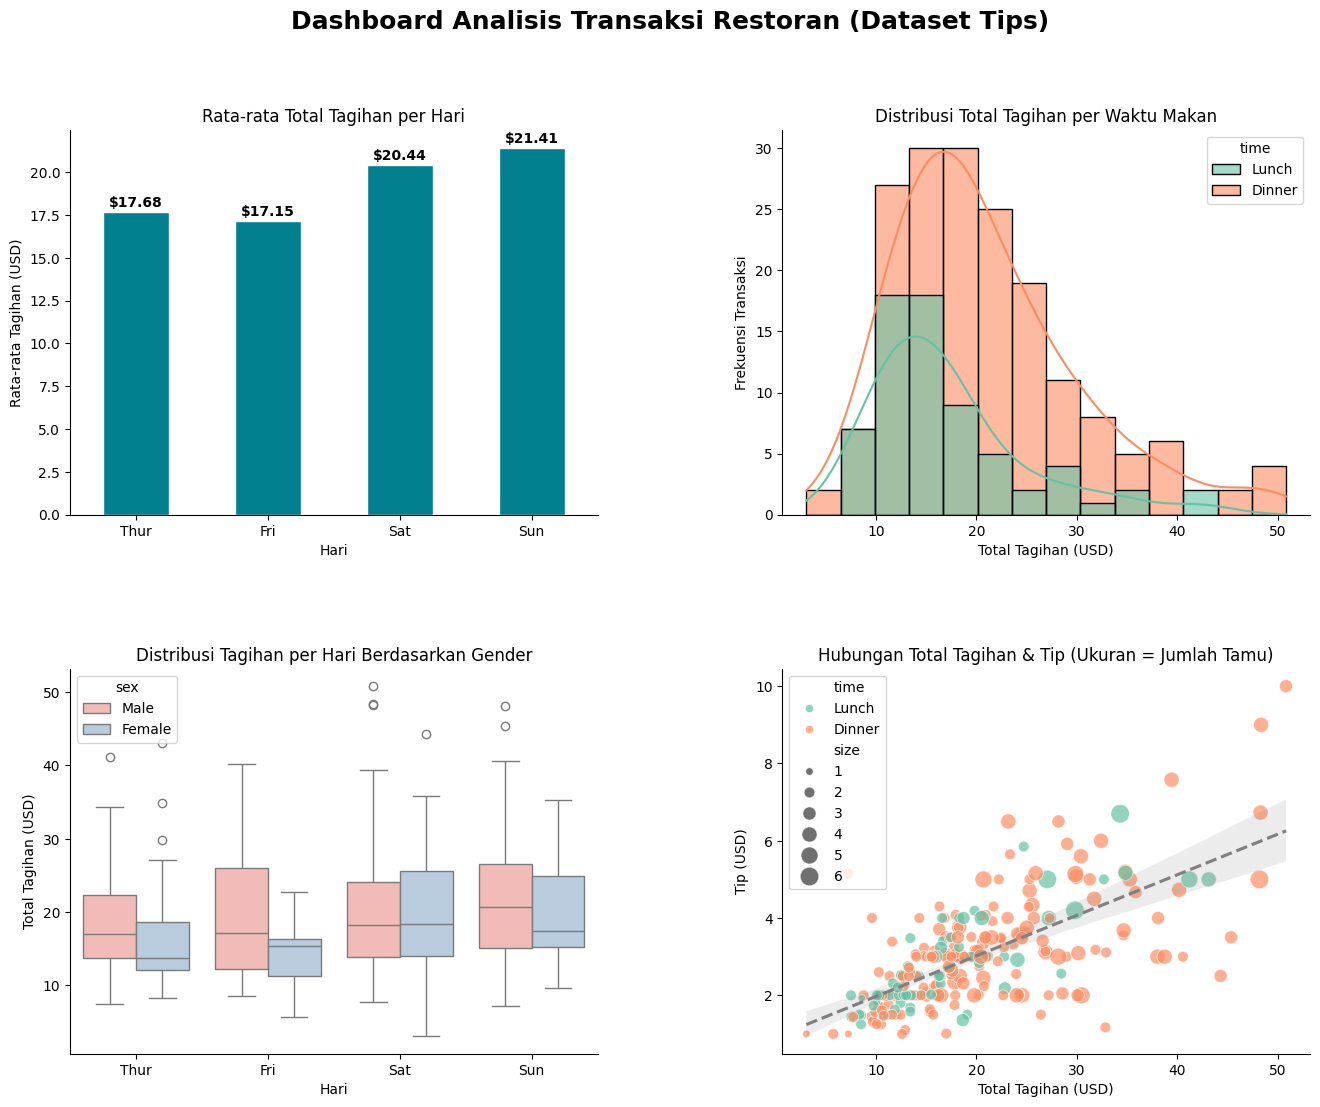

Dashboard tersimpan sebagai dashboard_tips.png


In [2]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns


# Menggunakan dataset 'tips'
df = sns.load_dataset('tips')
print("Ukuran dataset tips:", df.shape)
print("\nRingkasan Statistik Data Numerik:")
print(df.describe().round(2))
print("\nRata-rata Total Tagihan per Hari:")
print(df.groupby('day', observed=False)['total_bill'].mean().round(2))


fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Transaksi Restoran (Dataset Tips)',
             fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090', edgecolor='white')
ax1.set_title('Rata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Rata-rata Tagihan (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# Menambahkan label angka di atas bar
for i, v in enumerate(avg_by_day):
    ax1.text(i, v + 0.3, f"${v:.2f}", ha='center', fontweight='bold')

sns.histplot(data=df, x='total_bill', hue='time',
             kde=True, palette='Set2', alpha=0.6, ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.set_xlabel('Total Tagihan (USD)')
ax2.set_ylabel('Frekuensi Transaksi')
ax2.spines[['top','right']].set_visible(False)

sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Pastel1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari Berdasarkan Gender')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Tagihan (USD)')
ax3.spines[['top','right']].set_visible(False)


sns.scatterplot(data=df, x='total_bill', y='tip',
                hue='time', size='size', sizes=(30, 180),
                palette='Set2', alpha=0.7, ax=ax4)
# Menambahkan garis tren linear untuk melihat korelasi umum
sns.regplot(data=df, x='total_bill', y='tip',
            scatter=False, color='gray', ax=ax4, line_kws={"linestyle": "--"})
ax4.set_title('Hubungan Total Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.set_xlabel('Total Tagihan (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top','right']].set_visible(False)


plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')


### Grafik 1: Rata-rata Total Tagihan per Hari (Bar Chart)
* **What:** Sabtu dan Minggu memiliki rata-rata tagihan tertinggi (sekitar 20–21), sementara Kamis dan Jumat menghasilkan tagihan yang lebih rendah (17–18).
* **So what:** Weekend menghasilkan pendapatan lebih tinggi, kemungkinan karena pelanggan datang dalam kelompok lebih besar dan memesan lebih banyak.
* **Now what:** Perlu dieksplorasi apakah jumlah tamu (size) lebih besar di weekend dibanding weekday, dan apakah perlu penambahan staf di akhir pekan.

### Grafik 2: Distribusi Total Tagihan per Waktu Makan (Histogram + KDE)
* **What:** Distribusi total tagihan bersifat right-skewed (mean > median), dengan mayoritas tagihan berada di rentang 10–25 dollar. Dinner cenderung memiliki tagihan lebih tinggi dibanding Lunch.
* **So what:** Adanya right-skew menunjukkan ada sejumlah kecil meja dengan tagihan sangat tinggi yang menarik nilai rata-rata ke atas.
* **Now what:** Perlu diteliti siapa pelanggan dengan tagihan > 40 dollar — apakah meja besar atau pelanggan yang memesan menu premium tertentu.

### Grafik 3: Distribusi Tagihan per Hari & Gender (Boxplot)
* **What:** Pria (Male) secara konsisten memiliki median tagihan yang sedikit lebih tinggi dari wanita di semua hari. Sabtu memiliki sebaran (IQR) paling lebar, menandakan variasi tagihan paling tinggi.
* **So what:** Perbedaan tagihan antar gender mungkin mencerminkan perbedaan perilaku pemesanan, bukan sekadar perbedaan jumlah orang.
* **Now what:** Analisis lanjutan dapat meneliti apakah perbedaan ini signifikan secara statistik menggunakan uji Mann-Whitney atau t-test.

### Grafik 4: Hubungan Tagihan vs Tip (Scatter Plot)
* **What:** Terdapat korelasi positif sedang antara total tagihan dan jumlah tip (r ≈ 0.68). Semakin besar tagihan, tip cenderung lebih besar. Ukuran titik (jumlah tamu) tidak menunjukkan pola yang jelas terhadap tip.
* **So what:** Korelasi r = 0.68 menunjukkan hubungan yang cukup kuat namun tidak sempurna — ada pelanggan yang memberi tip besar meski tagihannya kecil.
* **Now what:** Perlu diteliti faktor lain yang mempengaruhi tip selain tagihan, seperti waktu makan, hari, atau apakah ada perokok di meja.